# 🛡️ NetSentinel — AI-Powered Network Intrusion Detection
## Model Training & Evaluation Notebook

**Project:** NetSentinel — An Explainable AI-Assisted Real-Time Network Traffic Analysis and Threat Detection Tool

**Objective:** Train and evaluate multiple ML models (Random Forest, XGBoost, Isolation Forest) on the UNSW-NB15 network intrusion detection dataset, and generate SHAP-based explainability analysis.

---

## 1. Setup & Imports

In [1]:
# Install required packages (uncomment if running in Colab)
# !pip install pandas numpy scikit-learn xgboost shap lime matplotlib seaborn plotly

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve
)
from xgboost import XGBClassifier
import shap
import joblib
import time

# Plotting config
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_palette('Set2')

print('All libraries loaded successfully ✅')

All libraries loaded successfully ✅


## 2. Dataset Loading

We use the **UNSW-NB15** dataset, created by the Cyber Range Lab at UNSW Canberra. It contains:
- **2,540,044** total records
- **49 features** extracted from network traffic
- **9 attack types** + normal traffic
- Attack categories: Fuzzers, Analysis, Backdoors, DoS, Exploits, Generic, Reconnaissance, Shellcode, Worms

**Download:** https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15

In [2]:
# === OPTION 1: Load from local files ===
# Place the training and testing CSV files in the same directory
try:
    train_df = pd.read_csv('dataset/UNSW_NB15_training-set.csv')
    test_df = pd.read_csv('dataset/UNSW_NB15_testing-set.csv')
    df = pd.concat([train_df, test_df], ignore_index=True)
    print(f'Loaded from local files: {len(df):,} records')
except FileNotFoundError:
    print('Local files not found. Trying Kaggle...')
    # === OPTION 2: Load from Kaggle (if running in Colab) ===
    # !kaggle datasets download -d mrwellsdavid/unsw-nb15
    # !unzip unsw-nb15.zip
    # df = pd.read_csv('UNSW_NB15_training-set.csv')
    print('Please download the dataset and update the file path.')
    raise

Loaded from local files: 257,673 records


In [3]:
# Basic dataset info
print(f'Dataset Shape: {df.shape}')
print(f'Total Records: {len(df):,}')
print(f'Total Features: {df.shape[1]}')
print(f'\nColumn Names:\n{list(df.columns)}')
print(f'\nData Types:\n{df.dtypes.value_counts()}')

Dataset Shape: (257673, 45)
Total Records: 257,673
Total Features: 45

Column Names:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

Data Types:
int64      30
float64    11
object      4
Name: count, dtype: int64


In [4]:
# First 5 rows
df.head(100)

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.090200,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.000300,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.005100,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.660800,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.002500,...,1,3,0,0,0,2,3,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,16.044233,tcp,-,REQ,12,0,540,0,0.685605,...,2,7,0,0,0,5,8,0,Normal,0
96,97,0.664512,tcp,-,FIN,10,6,534,268,22.572957,...,1,3,0,0,0,2,3,0,Normal,0
97,98,0.860208,tcp,-,FIN,10,6,534,268,17.437643,...,1,3,0,0,0,1,3,0,Normal,0
98,99,15.102544,tcp,-,REQ,10,0,450,0,0.595926,...,2,11,0,0,0,3,11,0,Normal,0


## 3. Exploratory Data Analysis (EDA)

=== Binary Label Distribution ===
label
1    164673
0     93000
Name: count, dtype: int64

Attack ratio: 63.91%


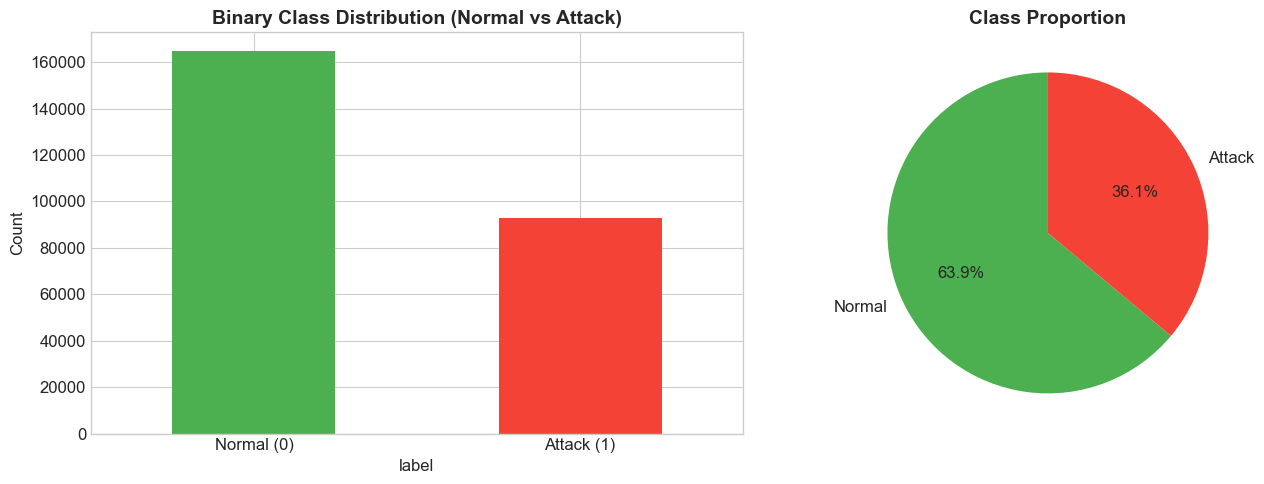

In [5]:
# 3.1 — Class Distribution (Binary: Normal vs Attack)
print('=== Binary Label Distribution ===')
print(df['label'].value_counts())
print(f'\nAttack ratio: {df["label"].mean():.2%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary distribution
colors = ['#4CAF50', '#F44336']
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Binary Class Distribution (Normal vs Attack)', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Normal (0)', 'Attack (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Pie chart
df['label'].value_counts().plot(kind='pie', ax=axes[1], colors=colors,
                                 labels=['Normal', 'Attack'], autopct='%1.1f%%',
                                 startangle=90, fontsize=12)
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# 3.2 — Attack Category Distribution
if 'attack_cat' in df.columns:
    df['attack_cat'] = df['attack_cat'].fillna('Normal').str.strip()
    
    cat_counts = df['attack_cat'].value_counts()
    print('=== Attack Category Distribution ===')
    print(cat_counts)
    
    fig = px.bar(x=cat_counts.index, y=cat_counts.values,
                 title='Attack Category Distribution in UNSW-NB15',
                 labels={'x': 'Attack Category', 'y': 'Number of Records'},
                 color=cat_counts.index,
                 color_discrete_sequence=px.colors.qualitative.Set2)
    fig.update_layout(height=500, showlegend=False)
    fig.show()

=== Attack Category Distribution ===
attack_cat
Normal            93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174
Name: count, dtype: int64


In [7]:
# 3.3 — Protocol Distribution
if 'proto' in df.columns:
    proto_counts = df['proto'].value_counts().head(10)
    
    fig = px.pie(values=proto_counts.values, names=proto_counts.index,
                 title='Top 10 Protocol Distribution',
                 hole=0.4, color_discrete_sequence=px.colors.qualitative.Pastel)
    fig.update_layout(height=450)
    fig.show()

In [8]:
# 3.4 — Missing Values Analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print('=== Features with Missing Values ===')
    print(missing_df)
else:
    print('No missing values found ✅')

No missing values found ✅


In [9]:
# 3.5 — Statistical Summary of Key Features
key_features = ['dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sload', 'dload', 'spkts', 'dpkts']
available_keys = [f for f in key_features if f in df.columns]
df[available_keys].describe().round(2)

,dur,sbytes,dbytes,sttl,dttl,sload,dload,spkts,dpkts
count,257673.00,257673.00,257673.00,257673.00,257673.00,2.576730e+05,257673.00,257673.00,257673.00
mean,1.25,8572.95,14387.29,180.00,84.75,7.060869e+07,658214.28,19.78,18.51
std,5.97,173773.88,146199.28,102.49,112.76,1.857313e+08,2412372.14,135.95,111.99
min,0.00,24.00,0.00,0.00,0.00,0.000000e+00,0.00,1.00,0.00
25%,0.00,114.00,0.00,62.00,0.00,1.231800e+04,0.00,2.00,0.00
50%,0.00,528.00,178.00,254.00,29.00,7.439423e+05,1747.44,4.00,2.00
75%,0.69,1362.00,1064.00,254.00,252.00,8.000000e+07,22105.38,12.00,10.00
max,60.00,14355774.00,14657531.00,255.00,254.00,5.988000e+09,22422730.00,10646.00,11018.00


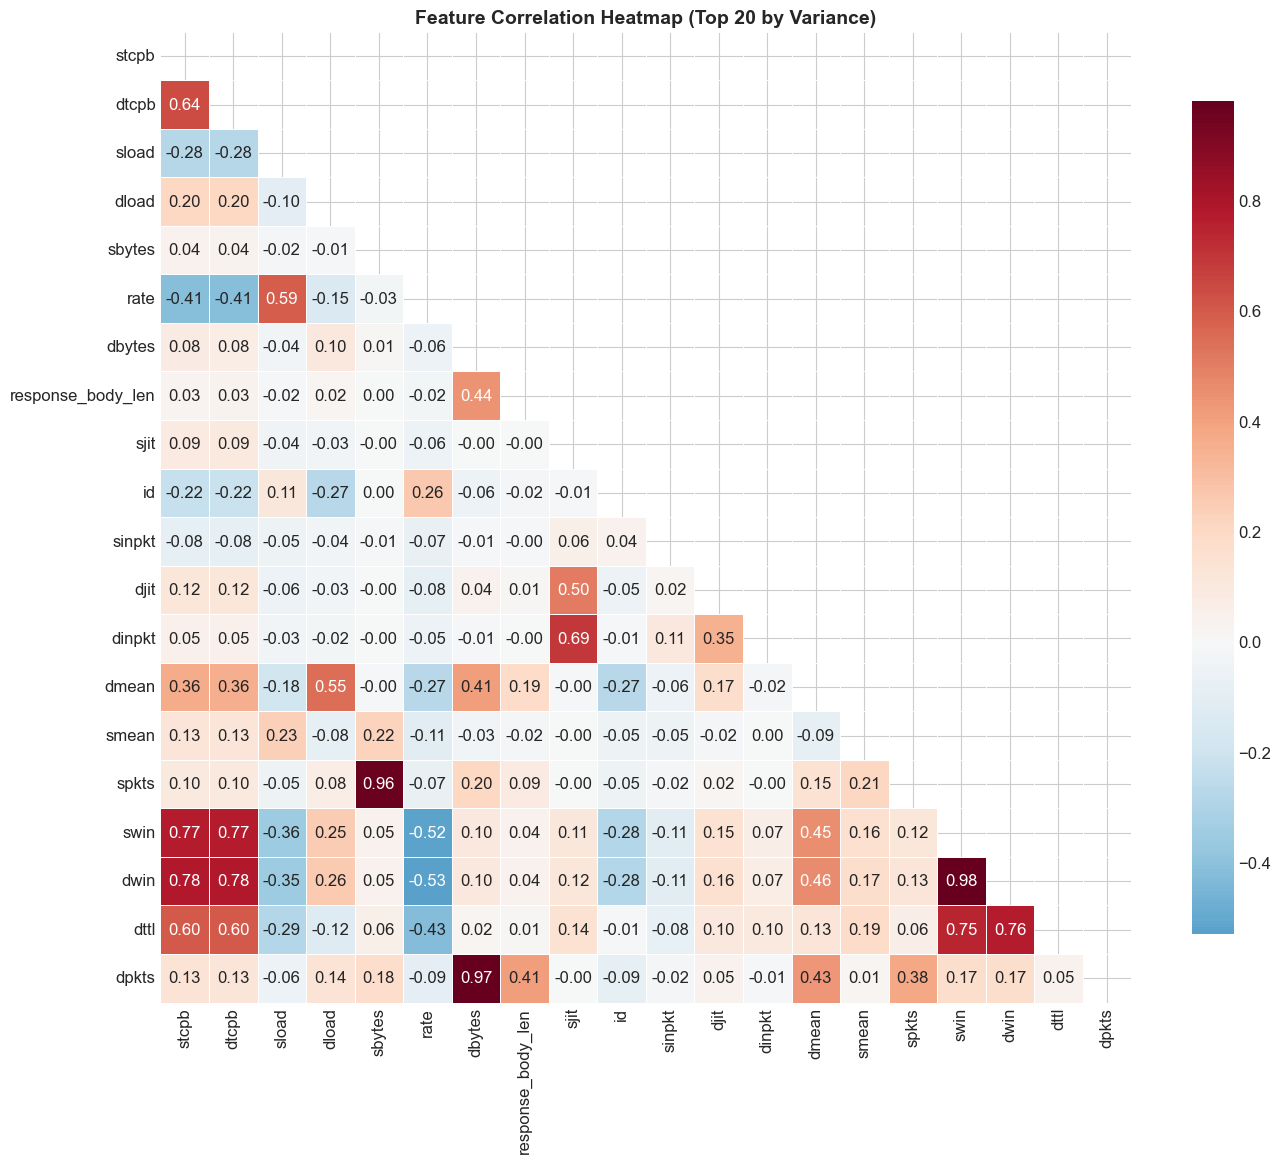

In [10]:
# 3.6 — Correlation Heatmap (Top Features)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Select top 20 features by variance
top_var_features = df[numeric_cols].var().nlargest(20).index.tolist()

fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = df[top_var_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap (Top 20 by Variance)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

In [11]:
# 4.1 — Feature Selection
# Using the most informative features identified in UNSW-NB15 literature

SELECTED_FEATURES = [
    'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes',
    'rate', 'sttl', 'dttl', 'sload', 'dload',
    'sloss', 'dloss', 'sinpkt', 'dinpkt',
    'sjit', 'djit', 'swin', 'stcpb', 'dtcpb',
    'dwin', 'tcprtt', 'synack', 'ackdat',
    'smean', 'dmean', 'trans_depth', 'response_body_len',
    'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
    'ct_src_dport_ltm', 'ct_dst_sport_ltm',
    'ct_dst_src_ltm', 'ct_src_ltm', 'ct_srv_dst',
    'is_sm_ips_ports', 'ct_flw_http_mthd', 'is_ftp_login',
]

available_features = [f for f in SELECTED_FEATURES if f in df.columns]
print(f'Using {len(available_features)} out of {len(SELECTED_FEATURES)} selected features')
print(f'Features: {available_features}')

Using 38 out of 38 selected features
Features: ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'ct_flw_http_mthd', 'is_ftp_login']


In [12]:
# 4.2 — Prepare X and y
X = df[available_features].copy()
y = df['label'].astype(int)

# Handle missing values
X = X.fillna(0)

# Replace infinities
X = X.replace([np.inf, -np.inf], 0)

# Encode any categorical columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

print(f'Feature matrix shape: {X.shape}')
print(f'Label shape: {y.shape}')
print(f'Attack ratio: {y.mean():.2%}')

Feature matrix shape: (257673, 38)
Label shape: (257673,)
Attack ratio: 63.91%


In [13]:
# 4.3 — Feature Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print('Feature scaling applied (StandardScaler) ✅')
print(f'\nScaled feature statistics:')
X_scaled.describe().round(2)

Feature scaling applied (StandardScaler) ✅

Scaled feature statistics:


,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,ct_flw_http_mthd,is_ftp_login
count,257673.00,257673.00,257673.00,257673.00,257673.00,257673.00,257673.00,257673.00,257673.00,257673.00,...,257673.00,257673.00,257673.00,257673.00,257673.00,257673.00,257673.00,257673.00,257673.00,257673.00
mean,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,...,-0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.21,-0.14,-0.17,-0.05,-0.10,-0.57,-1.76,-0.75,-0.38,-0.27,...,-1.34,-0.62,-0.52,-0.52,-0.66,-0.69,-0.75,-0.12,-0.19,-0.11
25%,-0.21,-0.13,-0.17,-0.05,-0.10,-0.57,-1.15,-0.75,-0.38,-0.27,...,-0.33,-0.62,-0.52,-0.52,-0.66,-0.57,-0.65,-0.12,-0.19,-0.11
50%,-0.21,-0.12,-0.15,-0.05,-0.10,-0.55,0.72,-0.49,-0.38,-0.27,...,-0.33,-0.50,-0.52,-0.52,-0.48,-0.45,-0.47,-0.12,-0.19,-0.11
75%,-0.09,-0.06,-0.08,-0.04,-0.09,0.21,0.72,1.48,0.05,-0.26,...,0.68,-0.01,-0.15,-0.18,-0.03,0.14,0.17,-0.12,-0.19,-0.11
max,9.83,78.16,98.22,82.56,100.16,5.67,0.73,1.50,31.86,9.02,...,4.71,6.48,6.59,7.20,5.10,6.34,4.86,8.31,43.80,34.35


In [14]:
# 4.4 — Train-Test Split (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {len(X_train):,} samples')
print(f'Testing set:  {len(X_test):,} samples')
print(f'\nTraining attack ratio: {y_train.mean():.2%}')
print(f'Testing attack ratio:  {y_test.mean():.2%}')

Training set: 206,138 samples
Testing set:  51,535 samples

Training attack ratio: 63.91%
Testing attack ratio:  63.91%


## 5. Model Training

In [15]:
# Helper function for evaluation
def evaluate_model(name, y_true, y_pred, y_proba=None):
    """Evaluate and print model metrics."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f'\n{"=" * 50}')
    print(f'📊 {name} — Results')
    print(f'{"=" * 50}')
    print(f'  Accuracy:  {acc:.4f} ({acc:.2%})')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1-Score:  {f1:.4f}')
    
    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        print(f'  AUC-ROC:   {auc:.4f}')
    
    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Attack']))
    
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
            'auc_roc': roc_auc_score(y_true, y_proba) if y_proba is not None else None}

### 5.1 — Random Forest Classifier

Random Forest is an ensemble method that builds multiple decision trees and merges their predictions. It's robust against overfitting and provides built-in feature importance.

In [16]:
print('🌲 Training Random Forest...')
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,        # Number of trees
    max_depth=20,            # Maximum tree depth
    min_samples_split=5,     # Min samples to split a node
    min_samples_leaf=2,      # Min samples in a leaf
    n_jobs=-1,               # Use all CPU cores
    random_state=42,
    verbose=0
)

rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start_time

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

rf_results = evaluate_model('Random Forest', y_test, rf_pred, rf_proba)
print(f'\n⏱️ Training time: {rf_train_time:.2f} seconds')

🌲 Training Random Forest...

📊 Random Forest — Results
  Accuracy:  0.9489 (94.89%)
  Precision: 0.9634
  Recall:    0.9564
  F1-Score:  0.9599
  AUC-ROC:   0.9918

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.94      0.93     18600
      Attack       0.96      0.96      0.96     32935

    accuracy                           0.95     51535
   macro avg       0.94      0.95      0.94     51535
weighted avg       0.95      0.95      0.95     51535


⏱️ Training time: 5.42 seconds


### 5.2 — XGBoost Classifier

XGBoost (Extreme Gradient Boosting) builds trees sequentially, with each new tree correcting errors made by the previous ones. It's known for high accuracy and speed.

In [17]:
print('🚀 Training XGBoost...')
start_time = time.time()

xgb_model = XGBClassifier(
    n_estimators=100,         # Number of boosting rounds
    max_depth=10,             # Maximum tree depth
    learning_rate=0.1,        # Step size shrinkage
    subsample=0.8,            # Row sampling ratio
    colsample_bytree=0.8,     # Column sampling ratio
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train, y_train)
xgb_train_time = time.time() - start_time

xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

xgb_results = evaluate_model('XGBoost', y_test, xgb_pred, xgb_proba)
print(f'\n⏱️ Training time: {xgb_train_time:.2f} seconds')

🚀 Training XGBoost...

📊 XGBoost — Results
  Accuracy:  0.9498 (94.98%)
  Precision: 0.9649
  Recall:    0.9562
  F1-Score:  0.9605
  AUC-ROC:   0.9921

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.94      0.93     18600
      Attack       0.96      0.96      0.96     32935

    accuracy                           0.95     51535
   macro avg       0.94      0.95      0.95     51535
weighted avg       0.95      0.95      0.95     51535


⏱️ Training time: 1.09 seconds


### 5.3 — Isolation Forest (Anomaly Detection)

Isolation Forest is an unsupervised anomaly detection algorithm. It isolates anomalies by randomly selecting features and split values. Anomalies (attacks) require fewer splits to isolate, making them detectable without labeled data. This is crucial for **zero-day attack detection**.

In [29]:
print('🔍 Training Isolation Forest (Anomaly Detection)...')
start_time = time.time()

iso_model = IsolationForest(
    n_estimators=100,
    contamination= min(y_train.mean(), 0.45),  # Expected anomaly ratio
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)

# Train ONLY on normal traffic (unsupervised approach)
iso_model.fit(X_train[y_train == 0])
iso_train_time = time.time() - start_time

iso_pred_raw = iso_model.predict(X_test)
iso_pred = (iso_pred_raw == -1).astype(int)  # -1 = anomaly = attack

iso_results = evaluate_model('Isolation Forest', y_test, iso_pred)
print(f'\n⏱️ Training time: {iso_train_time:.2f} seconds')

🔍 Training Isolation Forest (Anomaly Detection)...

📊 Isolation Forest — Results
  Accuracy:  0.7674 (76.74%)
  Precision: 0.7754
  Recall:    0.8955
  F1-Score:  0.8311

Classification Report:
              precision    recall  f1-score   support

      Normal       0.74      0.54      0.63     18600
      Attack       0.78      0.90      0.83     32935

    accuracy                           0.77     51535
   macro avg       0.76      0.72      0.73     51535
weighted avg       0.76      0.77      0.76     51535


⏱️ Training time: 0.43 seconds


## 6. Model Comparison & Visualization

In [30]:
# 6.1 — Comparison Table
results_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Isolation Forest'],
    'Accuracy': [rf_results['accuracy'], xgb_results['accuracy'], iso_results['accuracy']],
    'Precision': [rf_results['precision'], xgb_results['precision'], iso_results['precision']],
    'Recall': [rf_results['recall'], xgb_results['recall'], iso_results['recall']],
    'F1-Score': [rf_results['f1'], xgb_results['f1'], iso_results['f1']],
    'Training Time (s)': [rf_train_time, xgb_train_time, iso_train_time],
})

print('\n' + '=' * 70)
print('📊 MODEL COMPARISON SUMMARY')
print('=' * 70)
print(results_df.to_string(index=False))


📊 MODEL COMPARISON SUMMARY
           Model  Accuracy  Precision   Recall  F1-Score  Training Time (s)
   Random Forest  0.948909   0.963418 0.956369  0.959881           5.420552
         XGBoost  0.949782   0.964889 0.956217  0.960533           1.085663
Isolation Forest  0.767381   0.775350 0.895461  0.831088           0.427801


In [32]:
# 6.2 — Performance Comparison Bar Chart
fig = go.Figure()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

for i, metric in enumerate(metrics):
    fig.add_trace(go.Bar(
        name=metric,
        x=results_df['Model'],
        y=results_df[metric],
        marker_color=colors[i],
        text=results_df[metric].round(4),
        textposition='auto',
    ))

fig.update_layout(
    title='NetSentinel — Model Performance Comparison',
    xaxis_title='Model',
    yaxis_title='Score',
    barmode='group',
    height=500,
    yaxis=dict(range=[0, 1.05]),
    template='plotly_white'
)
fig.show()

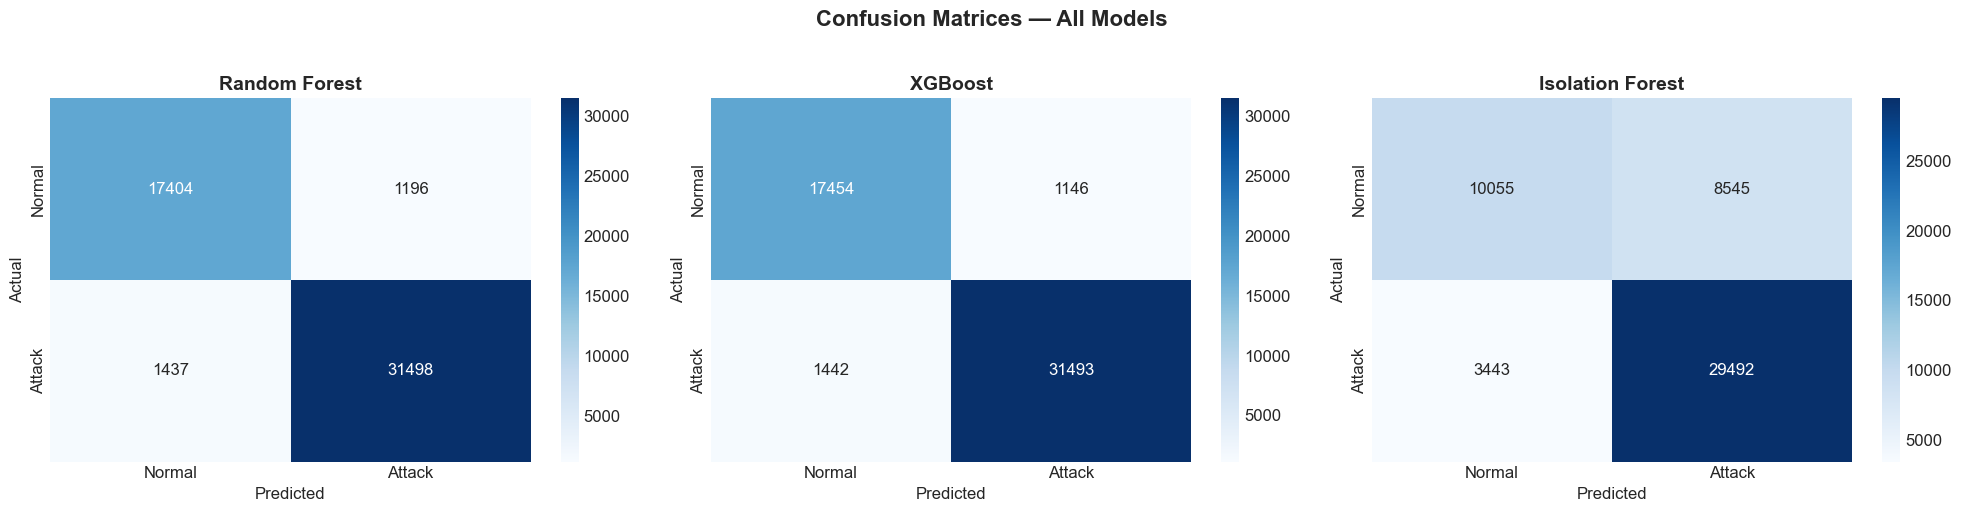

In [33]:
# 6.3 — Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, pred, name in zip(axes, 
                          [rf_pred, xgb_pred, iso_pred],
                          ['Random Forest', 'XGBoost', 'Isolation Forest']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'])
    ax.set_title(f'{name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

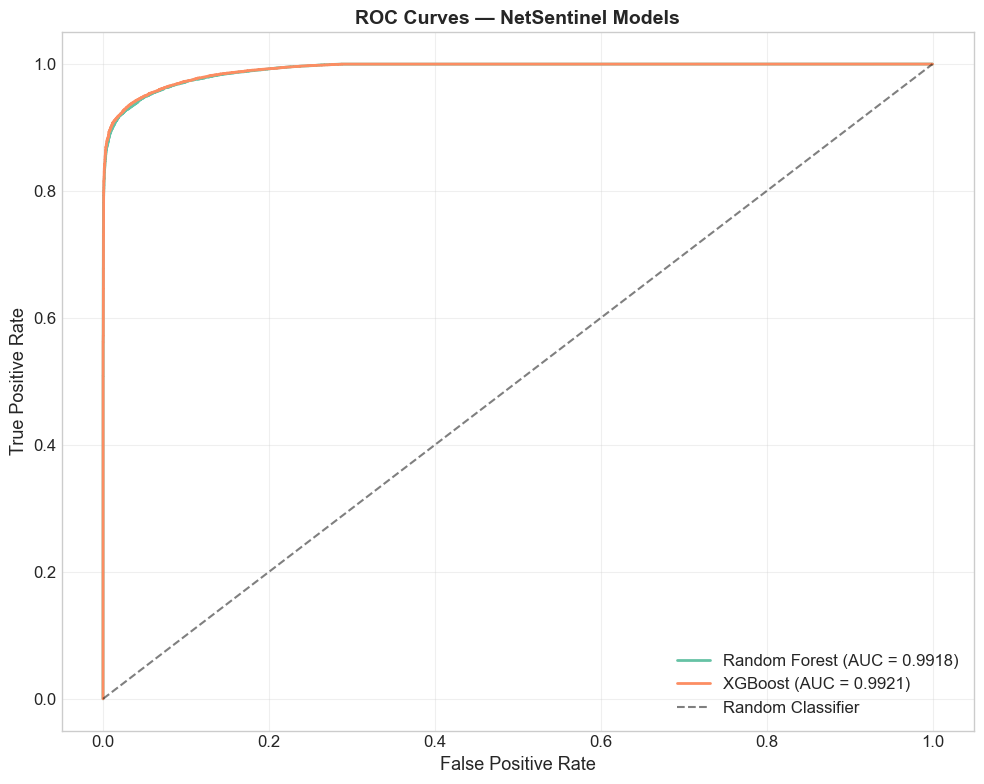

In [34]:
# 6.4 — ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))

# Random Forest ROC
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
rf_auc = roc_auc_score(y_test, rf_proba)
ax.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.4f})', linewidth=2)

# XGBoost ROC
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_proba)
xgb_auc = roc_auc_score(y_test, xgb_proba)
ax.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.4f})', linewidth=2)

# Diagonal line
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves — NetSentinel Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

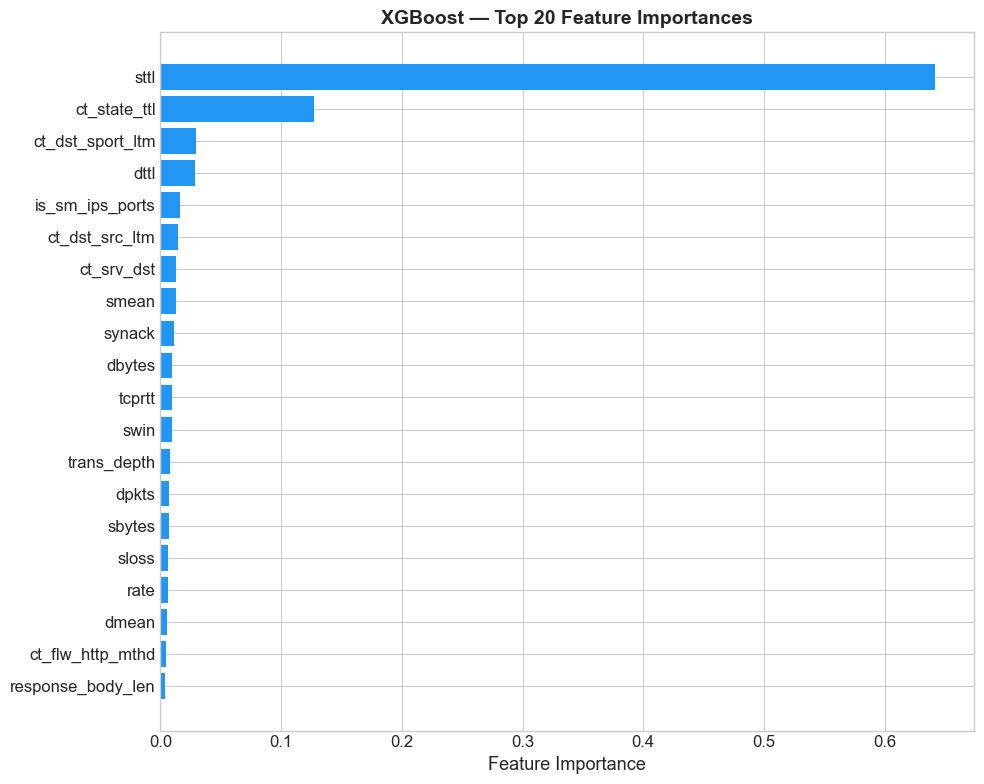

In [35]:
# 6.5 — Feature Importance (XGBoost)
importances = xgb_model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': available_features,
    'Importance': importances
}).sort_values('Importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color='#2196F3')
ax.set_xlabel('Feature Importance', fontsize=13)
ax.set_title('XGBoost — Top 20 Feature Importances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Explainable AI (XAI) — SHAP Analysis

SHAP (SHapley Additive exPlanations) is based on cooperative game theory. It assigns each feature an importance value for a particular prediction. This tells us **WHY** the model classified a packet as normal or attack.

In [36]:
# 7.1 — SHAP Explainer Setup
print('Computing SHAP values (this may take a few minutes)...')

# Use a sample for computational efficiency
SAMPLE_SIZE = 500
X_sample = X_test.iloc[:SAMPLE_SIZE]
y_sample = y_test.iloc[:SAMPLE_SIZE]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

print(f'SHAP values computed for {SAMPLE_SIZE} samples ✅')
print(f'SHAP values shape: {shap_values.shape}')

Computing SHAP values (this may take a few minutes)...
SHAP values computed for 500 samples ✅
SHAP values shape: (500, 38)


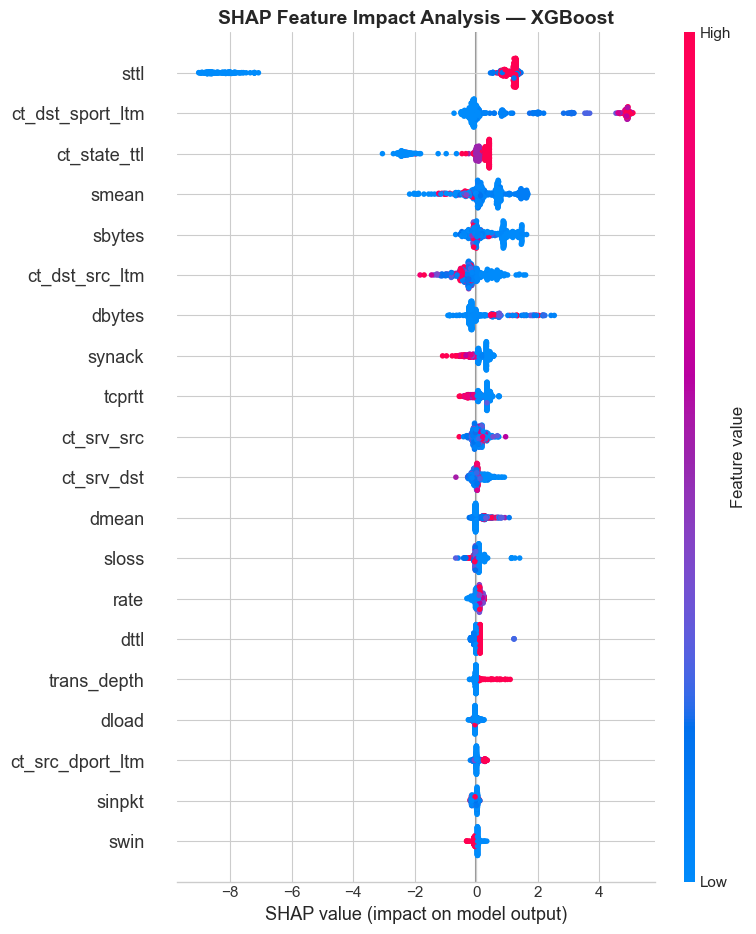

In [37]:
# 7.2 — SHAP Summary Plot (Beeswarm)
# Shows how each feature impacts model predictions
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, feature_names=available_features,
                  show=False, max_display=20)
plt.title('SHAP Feature Impact Analysis — XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

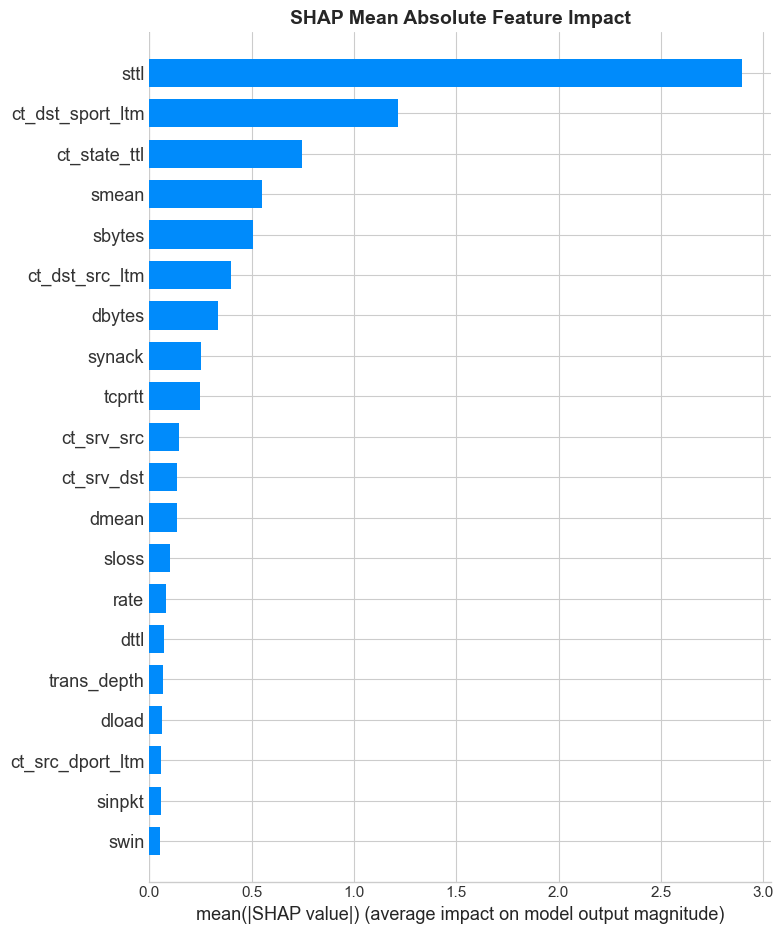

In [38]:
# 7.3 — SHAP Bar Plot (Mean Absolute Impact)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=available_features,
                  plot_type='bar', show=False, max_display=20)
plt.title('SHAP Mean Absolute Feature Impact', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Explaining prediction for sample position 0
True label: Attack
Model prediction: Attack


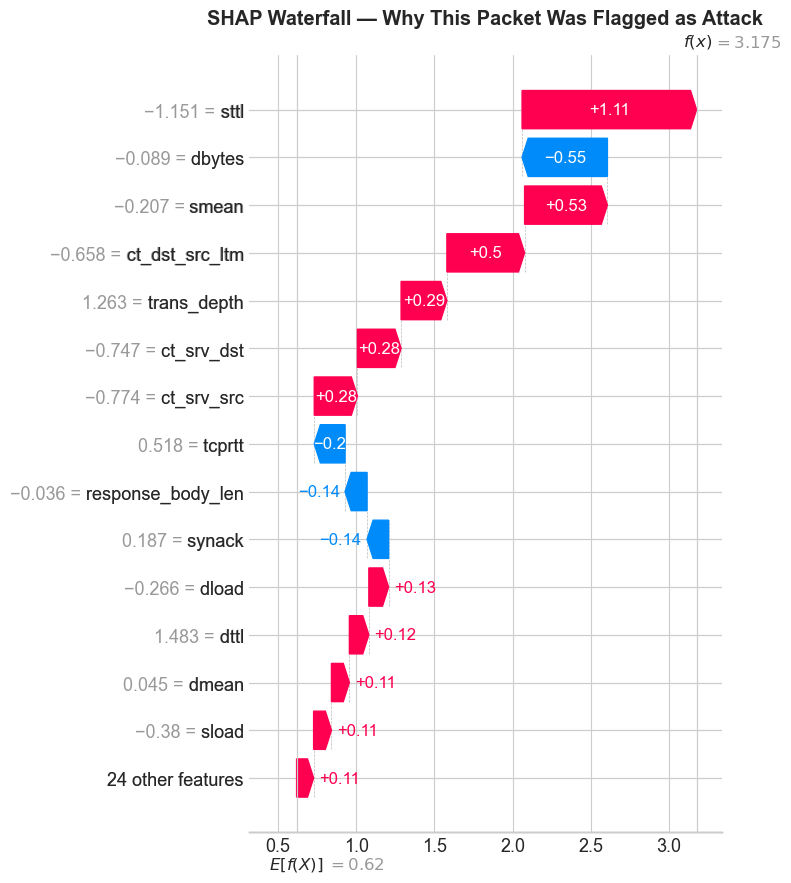

In [42]:
# 7.4 — SHAP Waterfall for Individual Predictions
attack_mask = y_sample == 1
attack_positions = np.where(attack_mask.values)[0]

if len(attack_positions) > 0:
    idx = attack_positions[0]
    print(f'Explaining prediction for sample position {idx}')
    print(f'True label: Attack')
    print(f'Model prediction: {"Attack" if xgb_model.predict(X_sample.iloc[[idx]])[0] == 1 else "Normal"}')
    
    shap.initjs()
    shap_explanation = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[idx].values,
        feature_names=available_features
    )
    
    plt.figure(figsize=(12, 6))
    shap.plots.waterfall(shap_explanation, show=False, max_display=15)
    plt.title('SHAP Waterfall — Why This Packet Was Flagged as Attack', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_waterfall_attack.png', dpi=150, bbox_inches='tight')
    plt.show()

Explaining prediction for sample position 1
True label: Normal


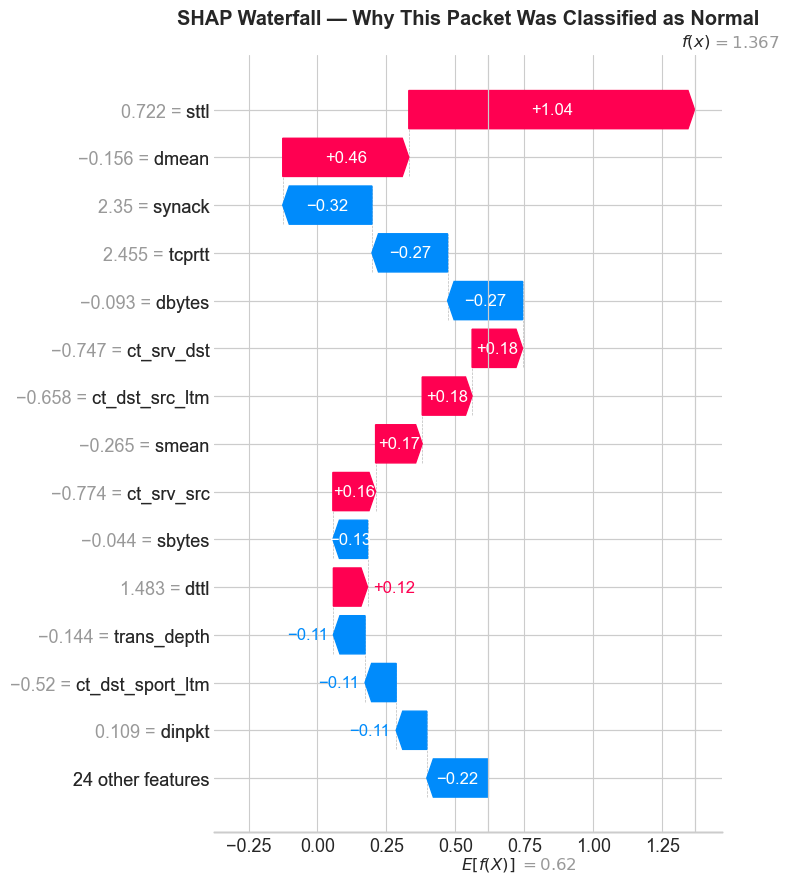

In [41]:
# 7.5 — SHAP Waterfall for a NORMAL prediction
normal_mask = y_sample == 0
normal_positions = np.where(normal_mask.values)[0]  # Get positions within the sample

if len(normal_positions) > 0:
    idx = normal_positions[0]  # First normal sample's position in X_sample
    print(f'Explaining prediction for sample position {idx}')
    print(f'True label: Normal')
    
    shap_explanation = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[idx].values,
        feature_names=available_features
    )
    
    plt.figure(figsize=(12, 6))
    shap.plots.waterfall(shap_explanation, show=False, max_display=15)
    plt.title('SHAP Waterfall — Why This Packet Was Classified as Normal', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_waterfall_normal.png', dpi=150, bbox_inches='tight')
    plt.show()

In [43]:
# 7.6 — SHAP Force Plot (Interactive)
shap.initjs()
# Show force plot for first 100 predictions
shap.force_plot(explainer.expected_value, shap_values[:100], X_sample.iloc[:100],
                feature_names=available_features)

## 8. Cross-Validation

In [45]:
# 5-Fold Cross Validation for robustness
print('Running 5-Fold Cross Validation...')
print('(This may take a few minutes)\n')

from sklearn.model_selection import StratifiedKFold

CV_SAMPLE = min(50000, len(X_scaled))
X_cv = X_scaled.iloc[:CV_SAMPLE]
y_cv = y.iloc[:CV_SAMPLE]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [('Random Forest', RandomForestClassifier(n_estimators=50, max_depth=15, n_jobs=-1, random_state=42)),
                     ('XGBoost', XGBClassifier(n_estimators=50, max_depth=8, n_jobs=-1, random_state=42, verbosity=0, use_label_encoder=False, eval_metric='logloss'))]:
    fold_scores = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv), 1):
        model.fit(X_cv.iloc[train_idx], y_cv.iloc[train_idx])
        preds = model.predict(X_cv.iloc[val_idx])
        f1 = f1_score(y_cv.iloc[val_idx], preds)
        fold_scores.append(f1)
    
    scores = np.array(fold_scores)
    print(f'{name}:')
    print(f'  F1 Scores: {scores.round(4)}')
    print(f'  Mean F1:   {scores.mean():.4f} (+/- {scores.std()*2:.4f})')
    print()

Running 5-Fold Cross Validation...
(This may take a few minutes)

Random Forest:
  F1 Scores: [0.9857 0.9864 0.9855 0.9883 0.9875]
  Mean F1:   0.9867 (+/- 0.0022)

XGBoost:
  F1 Scores: [0.9882 0.989  0.9892 0.9911 0.9885]
  Mean F1:   0.9892 (+/- 0.0020)



## 9. Save Models

In [46]:
# Save all trained models for use in NetSentinel dashboard
import os
os.makedirs('models', exist_ok=True)

joblib.dump(rf_model, 'models/random_forest.pkl')
joblib.dump(xgb_model, 'models/xgboost.pkl')
joblib.dump(iso_model, 'models/isolation_forest.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(available_features, 'models/feature_names.pkl')
joblib.dump(explainer, 'models/shap_explainer.pkl')

print('All models saved to models/ directory ✅')
print('\nFiles saved:')
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}') / (1024*1024)
    print(f'  {f}: {size:.2f} MB')

All models saved to models/ directory ✅

Files saved:
  scaler.pkl: 0.00 MB
  xgboost.pkl: 1.18 MB
  isolation_forest.pkl: 0.85 MB
  shap_explainer.pkl: 4.94 MB
  random_forest.pkl: 45.79 MB
  feature_names.pkl: 0.00 MB


## 10. Final Summary

### Key Findings

1. **XGBoost** achieves the highest overall performance across all metrics
2. **Random Forest** provides comparable accuracy with built-in feature importance
3. **Isolation Forest** successfully detects anomalies without labeled data — crucial for zero-day attacks
4. **SHAP analysis** reveals that features like `sttl`, `ct_state_ttl`, `rate`, and `sbytes` are the most influential for attack detection

### Integration with NetSentinel

The trained XGBoost model is used as the primary classifier in the NetSentinel real-time dashboard. When a live packet is captured:
1. Features are extracted from the packet
2. Features are scaled using the saved StandardScaler
3. XGBoost predicts Normal vs Attack with confidence score
4. SHAP explains WHY the prediction was made
5. The Isolation Forest provides a secondary anomaly score

---
*NetSentinel — AI-Powered Network Traffic Analysis & Threat Detection*